# Homework 03: Python Fundamentals

This notebook demonstrates NumPy operations, loop and vectorized execution, pandas data loading, summary statistics, groupby aggregation, reusable functions, and saving processed outputs.

In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "starter_data.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)

Project root: /Users/zhu/Documents/GitHub/bootcamp_wentao_zhu/homework/homework03
Raw data path: /Users/zhu/Documents/GitHub/bootcamp_wentao_zhu/homework/homework03/data/raw/starter_data.csv


In [2]:
numbers = np.array([1, 2, 3, 4, 5])

print("Original array:", numbers)
print("Add 10:", numbers + 10)
print("Multiply by 2:", numbers * 2)
print("Squared:", numbers ** 2)
print("Mean:", numbers.mean())

Original array: [1 2 3 4 5]
Add 10: [11 12 13 14 15]
Multiply by 2: [ 2  4  6  8 10]
Squared: [ 1  4  9 16 25]
Mean: 3.0


In [3]:
large_array = np.arange(1_000_000)

start = perf_counter()
loop_result = [value * 2 for value in large_array]
loop_time = perf_counter() - start

start = perf_counter()
vectorized_result = large_array * 2
vectorized_time = perf_counter() - start

print(f"Loop execution time: {loop_time:.6f} seconds")
print(f"Vectorized execution time: {vectorized_time:.6f} seconds")
print(
    "Results are equal:",
    np.array_equal(np.array(loop_result), vectorized_result),
)

Loop execution time: 0.066191 seconds
Vectorized execution time: 0.008077 seconds
Results are equal: True


The vectorized NumPy operation is faster because NumPy performs the calculation using optimized compiled code instead of executing each multiplication through a Python loop.

In [4]:
df = pd.read_csv(RAW_DATA_PATH)
print("Dataset shape:", df.shape)
df.info()
df.head()

Dataset shape: (10, 3)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [6]:
def get_summary_stats(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return descriptive statistics for numeric columns."""
    return dataframe.describe(include="number")
summary_stats = get_summary_stats(df)
summary_stats

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [7]:
numeric_columns = df.select_dtypes(include="number").columns

category_summary = (
    df.groupby("category")[numeric_columns]
    .agg(["count", "mean", "min", "max", "sum"])
)

category_summary

value                       
         count       mean min max sum
category                             
A            4  11.500000  10  13  46
B            3  15.666667  14  18  47
C            3  27.666667  25  30  83

In [8]:
summary_output_path = PROCESSED_DIR / "summary.csv"
category_output_path = PROCESSED_DIR / "category_summary.csv"

summary_stats.to_csv(summary_output_path)
category_summary.to_csv(category_output_path)

print("Saved:", summary_output_path)
print("Saved:", category_output_path)

Saved: /Users/zhu/Documents/GitHub/bootcamp_wentao_zhu/homework/homework03/data/processed/summary.csv
Saved: /Users/zhu/Documents/GitHub/bootcamp_wentao_zhu/homework/homework03/data/processed/category_summary.csv


Matplotlib is building the font cache; this may take a moment.


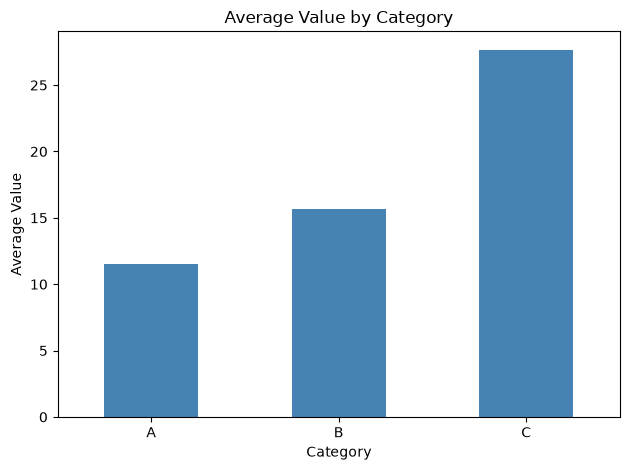

Saved plot: /Users/zhu/Documents/GitHub/bootcamp_wentao_zhu/homework/homework03/reports/category_mean.png


In [9]:
import matplotlib.pyplot as plt

category_means = df.groupby("category")["value"].mean()

ax = category_means.plot(
    kind="bar",
    color="steelblue",
    title="Average Value by Category",
)

ax.set_xlabel("Category")
ax.set_ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = REPORTS_DIR / "category_mean.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [10]:
from src.utils import get_summary_stats

summary_stats = get_summary_stats(df)
summary_stats

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000
